# USR Higgs Power Loss: $P_{\mathcal{S}}(k)$ and CMB $D_\ell$

Reproduces the two key figures from the USR physics discussion:

- **Fig 1:** Primordial power spectrum $\mathcal{P}_{\mathcal{R}}(k)$ — USR Higgs vs power-law
- **Fig 2:** CMB $D_\ell^{TT}$ — Sachs-Wolfe approximation vs Planck 2018 low-$\ell$ data

**Data:** Planck 2018 Commander binned TT spectrum (IRSA R3, official data)


In [23]:
import os, sys
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

import glob
import numpy as np
import matplotlib.pyplot as plt

from pspectrum_pipeline import load_pspectrum
from scripts.camb_wrapper import compute_cl_sw, compute_cl_sw_powerlaw
from scripts.planck_data import get_planck_data
from scripts.constants import As, k_pivot_phys, r_ls, T_cmb
from models import HiggsModel


## Configuration

Edit these parameters to test different USR scenarios.


In [24]:
PHI0 = 5.76
YI = -0.12
XI = 15000.0
LAM = 0.13
RECOMPUTE = False  # set True to force fresh pipeline run

CACHE_DIR = os.path.join(ROOT_DIR, "outputs/cmb_results/pspectra")
OUTPUT_DIR = os.path.join(ROOT_DIR, "outputs/powerloss/plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"USR: phi0={PHI0}, y0={Y0}, xi={XI}")


USR: phi0=5.76, yi=-0.12, xi=15000.0


## Load or compute $P_{\mathcal{S}}(k)$


In [25]:
pattern = f"*_phi{PHI0:.2f}_yi{YI:.3f}_run_*.json"
matches = sorted(glob.glob(os.path.join(CACHE_DIR, pattern)),
                 key=os.path.getmtime, reverse=True)

if matches and not RECOMPUTE:
    cache_path = matches[0]
    print(f"Loading cached P_S(k) from {cache_path}...")
    cached = load_pspectrum(cache_path)
    k_phys = cached["k_phys"]
    P_S = cached["P_S"]
    meta = cached["metadata"]
    print(f"  {len(k_phys)} k-modes loaded")
else:
    print("Computing P_S(k) pipeline...")
    from pspectrum_pipeline import run_pspectrum_pipeline, build_weighted_kgrid
    model = HiggsModel(lam=LAM, xi=XI)
    k_grid = build_weighted_kgrid(k_min=1e-5, k_max=1.0, k_pivot_phys=k_pivot_phys,
                                  n_dense=200, n_outer=100)
    result = run_pspectrum_pipeline(model=model, phi0=PHI0, yi=YI,
                                    k_phys_grid=k_grid,
                                    normalize_to_As=True, As=As,
                                    n_workers=max(1, os.cpu_count()//2))
    k_phys = result["k_phys"]
    P_S = result["P_S"]
    meta = result["metadata"]

print(f"  N_total = {meta['N_total']:.2f},  N_pivot = {meta['N_pivot']:.2f}")


Loading cached P_S(k) from c:\Users\diego\OneDrive\Documentos\Universidad\Cosmologia\CMB_Anomaly\outputs/cmb_results/pspectra\Higgs_Inflation_phi5.76_yi-0.120_run_42bffdf2.json...
  299 k-modes loaded
  N_total = 63.09,  N_pivot = 3.09


## Compute LCDM baseline and $C_\ell$


In [26]:
# LCDM power-law spectrum
ns_lcdm = 0.965
P_S_lcdm = As * (k_phys / k_pivot_phys) ** (ns_lcdm - 1.0)

# Sachs-Wolfe C_ell
ell_max = 29
print("Computing C_ell via Sachs-Wolfe...")
ells, C_ell_usr = compute_cl_sw({"k_phys": k_phys, "P_S": P_S}, ell_max=ell_max, r_ls=r_ls)
_, C_ell_lcdm, P_S_lcdm_dense = compute_cl_sw_powerlaw(
    As=As, ns=ns_lcdm, k_pivot=k_pivot_phys, ell_max=ell_max, r_ls=r_ls
)

# Convert to D_ell [muK^2]
T_factor = (T_cmb * 1e6) ** 2
D_ell_usr = C_ell_usr * ells * (ells + 1.0) * T_factor / (2.0 * np.pi)
D_ell_lcdm = C_ell_lcdm * ells * (ells + 1.0) * T_factor / (2.0 * np.pi)

# Planck data
planck_ells, planck_D, planck_err = get_planck_data()


Computing C_ell via Sachs-Wolfe...


## Figure 1: $P_{\mathcal{S}}(k)$ — USR Higgs vs Power-law


Saved: outputs/powerloss/plots/fig1_ps_usr_vs_powerlaw.png


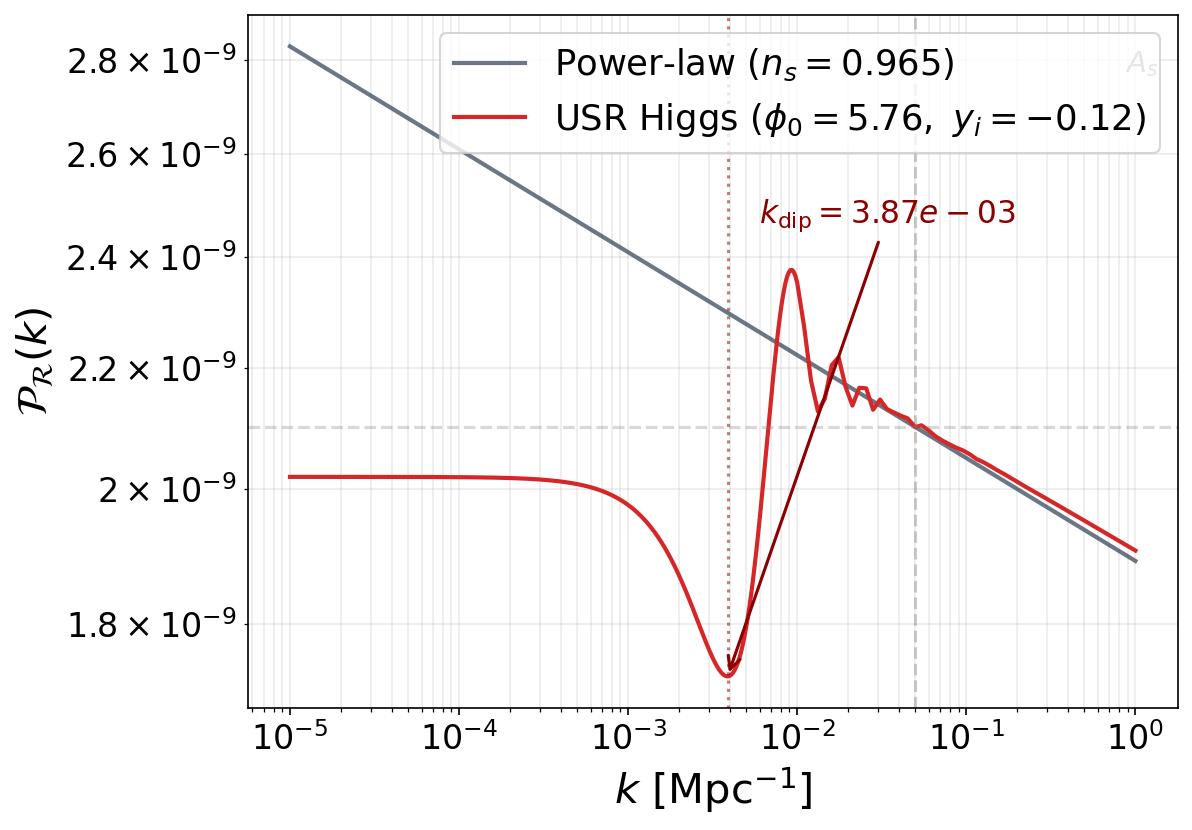

In [27]:
COL_USR = "#d62728"
COL_LCDM = "#2c3e50"
COL_DIP = "darkred"
COL_DATA = "#1f77b4"

plt.rcParams.update({
    "font.size": 16, "axes.labelsize": 20, "axes.titlesize": 22,
    "xtick.labelsize": 16, "ytick.labelsize": 16, "legend.fontsize": 17,
    "figure.dpi": 150,
})

fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.loglog(k_phys, P_S_lcdm, "-", color=COL_LCDM, lw=2, alpha=0.7,
           label=r"Power-law ($n_s = 0.965$)" )
usr_label = f"USR Higgs ($\\phi_0={PHI0},\\ y_i = {YI}$)"
ax1.loglog(k_phys, P_S, "-", color=COL_USR, lw=2, label=usr_label)

k_dip = k_phys[np.argmin(P_S[k_phys < 1.0])]
P_dip = P_S[k_phys < 1.0][np.argmin(P_S[k_phys < 1.0])]
ax1.axvline(k_dip, color=COL_DIP, ls=":", lw=1.5, alpha=0.5)
ax1.annotate(rf"$k_{{\rm dip}} = {k_dip:.2e}$", xy=(k_dip, P_dip),
             xytext=(0.55, 0.7), textcoords="axes fraction",
             arrowprops=dict(arrowstyle="->", color=COL_DIP, lw=1.5),
             fontsize=15, color=COL_DIP)

ax1.axvline(k_pivot_phys, color="gray", ls="--", lw=1.5, alpha=0.4)
ax1.annotate(r"$k_* = 0.05$", xy=(k_pivot_phys, As * 0.6),
             xytext=(0.02, 0.1), textcoords="axes fraction",
             fontsize=14, color="gray")
ax1.axhline(As, color="gray", ls="--", lw=1.5, alpha=0.3)
ax1.text(0.98, 0.95, r"$A_s$", transform=ax1.transAxes,
         fontsize=14, color="gray", ha="right", va="top")

ax1.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
ax1.legend()
ax1.set_ylabel(r"$\mathcal{P}_{\mathcal{R}}(k)$")
ax1.grid(True, alpha=0.25, which="both")

fig1.savefig(os.path.join(OUTPUT_DIR, "fig1_ps_usr_vs_powerlaw.png"),
             dpi=300, bbox_inches="tight")
print(f"Saved: outputs/powerloss/plots/fig1_ps_usr_vs_powerlaw.png")
plt.show()


## Figure 2: CMB $D_\ell$ — Sachs-Wolfe vs Planck low-$\ell$


Saved: outputs/powerloss/plots/fig2_dell_usr_vs_planck.png


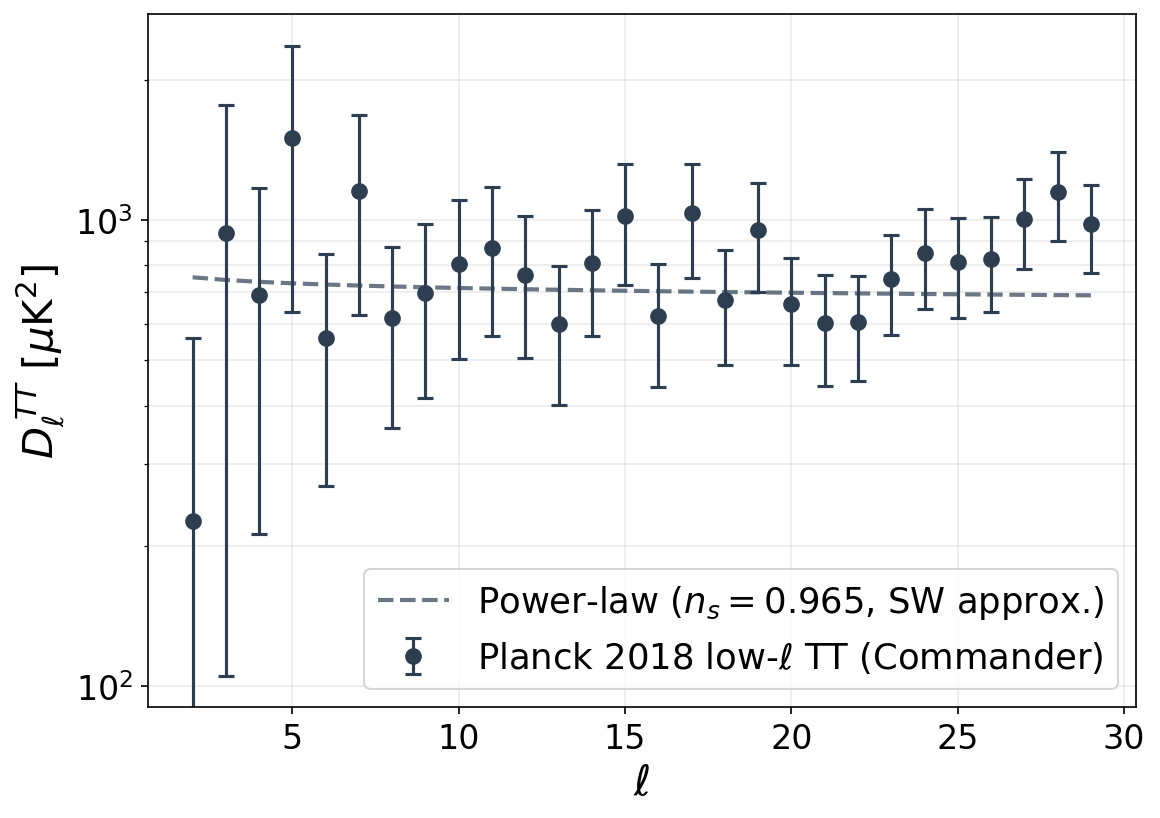

In [28]:
fig2, ax2 = plt.subplots(figsize=(8.5, 6))
ax2.errorbar(planck_ells, planck_D, yerr=planck_err,
             fmt="o", color="#2c3e50", capsize=4, capthick=1.5,
             markersize=7, elinewidth=1.5,
             label=r"Planck 2018 low-$\ell$ TT (Commander)")

usr_label2 = f"USR Higgs ($\\phi_0={PHI0},\\ y_i = {YI}$)"
usr_label2 = f"USR Higgs ($\\phi_0={PHI0},\\ y_i = {YI}$)"
ax2.semilogy(ells, D_ell_lcdm, "--", color=COL_LCDM, lw=2, alpha=0.7,
             label=r"Power-law ($n_s = 0.965$, SW approx.)")

ax2.set_xlabel(r"$\ell$")
ax2.set_ylabel(r"$D_\ell^{\,TT}\ [\mu{\rm K}^2]$")
ax2.legend()
ax2.grid(True, alpha=0.25, which="both")

fig2.savefig(os.path.join(OUTPUT_DIR, "fig2_dell_usr_vs_planck.png"),
             dpi=300, bbox_inches="tight")
print(f"Saved: outputs/powerloss/plots/fig2_dell_usr_vs_planck.png")
plt.show()


## Visualizing the Lack of Power (Low-$\ell$ Anomaly)

The community often discusses the "lack of power" by plotting the CMB $TT$ power spectrum on a linear scale, zoomed in on $\ell \le 30$. In this region, a standard power-law ($\Lambda$CDM) model predicts more power than what Planck actually observed. By introducing a USR phase, the primordial power at large scales is suppressed, bringing the theoretical prediction closer to the data points, especially near the quadrupole ($\ell=2$) and $\ell \sim 20$.

The plot below shows both the absolute $D_\ell^{TT}$ and the fractional difference relative to the standard power-law, including cosmic variance.

Saved: outputs/powerloss/plots/fig2b_anomaly_zoom.png


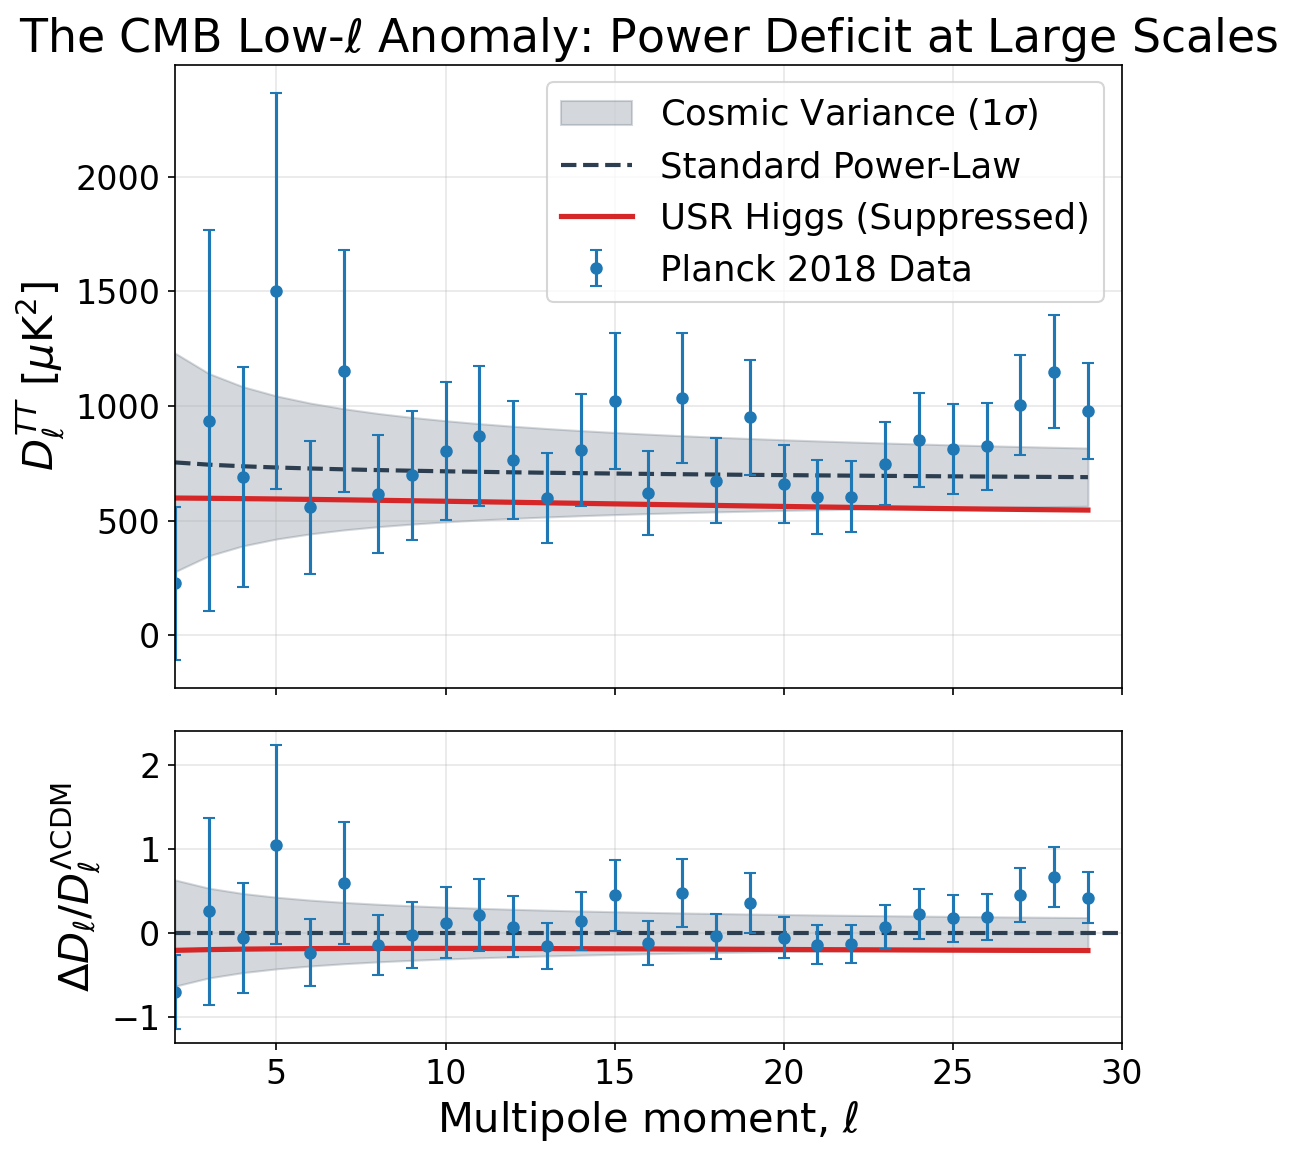

In [29]:
fig_anomaly, (ax_abs, ax_rel) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                             gridspec_kw={'height_ratios': [2, 1]})

mask_ell = ells <= 30
ells_low = ells[mask_ell]
D_usr_low = D_ell_usr[mask_ell]
D_lcdm_low = D_ell_lcdm[mask_ell]

# Cosmic variance for TT is sqrt(2/(2*ell+1)) * D_ell
cosmic_var_lcdm = np.sqrt(2.0 / (2.0 * ells_low + 1.0)) * D_lcdm_low

# Top panel: Absolute D_ell
ax_abs.fill_between(ells_low, D_lcdm_low - cosmic_var_lcdm, D_lcdm_low + cosmic_var_lcdm,
                    color=COL_LCDM, alpha=0.2, label="Cosmic Variance ($1\\sigma$)")
ax_abs.plot(ells_low, D_lcdm_low, "--", color=COL_LCDM, lw=2, label="Standard Power-Law")
ax_abs.plot(ells_low, D_usr_low, "-", color=COL_USR, lw=2.5, label="USR Higgs (Suppressed)")

ax_abs.errorbar(planck_ells, planck_D, yerr=planck_err,
                fmt="o", color=COL_DATA, markersize=5, capsize=3, label="Planck 2018 Data")

ax_abs.set_ylabel(r"$D_\ell^{TT}\ [\mu{\rm K}^2]$")
ax_abs.set_title("The CMB Low-$\\ell$ Anomaly: Power Deficit at Large Scales")
ax_abs.legend()
ax_abs.grid(True, alpha=0.3)

# Bottom panel: Fractional difference relative to LCDM
rel_usr = (D_usr_low - D_lcdm_low) / D_lcdm_low

# Interpolate planck data to LCDM ell grid
lcdm_at_planck = np.interp(planck_ells, ells_low, D_lcdm_low)
rel_planck = (planck_D - lcdm_at_planck) / lcdm_at_planck
rel_planck_err = planck_err / lcdm_at_planck
rel_cv = cosmic_var_lcdm / D_lcdm_low

ax_rel.fill_between(ells_low, -rel_cv, rel_cv, color=COL_LCDM, alpha=0.2)
ax_rel.axhline(0, color=COL_LCDM, linestyle="--", lw=2)
ax_rel.plot(ells_low, rel_usr, "-", color=COL_USR, lw=2.5)
ax_rel.errorbar(planck_ells, rel_planck, yerr=rel_planck_err,
                fmt="o", color=COL_DATA, markersize=5, capsize=3)

ax_rel.set_xlabel(r"Multipole moment, $\ell$")
ax_rel.set_ylabel(r"$\Delta D_\ell / D_\ell^{\Lambda\text{CDM}}$")
ax_rel.set_xlim(2, 30)
ax_rel.grid(True, alpha=0.3)

plt.tight_layout()
fig_anomaly.savefig(os.path.join(OUTPUT_DIR, "fig2b_anomaly_zoom.png"), dpi=300, bbox_inches="tight")
print(f"Saved: outputs/powerloss/plots/fig2b_anomaly_zoom.png")
plt.show()


## Power loss metrics


In [30]:
loss_vs_lcdm = (P_S - P_S_lcdm) / P_S_lcdm * 100
k_dip_val = k_dip
P_dip_ratio = P_dip / As

print(f"k_dip [Mpc-1]                          {k_dip_val:.3e}")
print(f"P_R(k_dip)/A_s                          {P_dip_ratio:.4f}")
print(f"Power loss at dip vs LCDM [%]           {loss_vs_lcdm[k_phys < 1.0].min():.1f}")

k_ell30 = 30 / r_ls
i30 = np.abs(k_phys - k_ell30).argmin()
print(f"At ell~30: P_S/A_s = {P_S[i30]/As:.4f}, loss = {loss_vs_lcdm[i30]:.1f}%")


k_dip [Mpc-1]                          3.872e-03
P_R(k_dip)/A_s                          0.8226
Power loss at dip vs LCDM [%]           -28.6
At ell~30: P_S/A_s = 0.8835, loss = -20.9%


In [31]:
import numpy as np

# Create masks to align the theoretical ells with the Planck data ells
mask = np.isin(ells, planck_ells)
mask_planck = np.isin(planck_ells, ells)

theory_lcdm = D_ell_lcdm[mask]
theory_usr = D_ell_usr[mask]
obs_D = planck_D[mask_planck]
obs_err = planck_err[mask_planck]

# Calculate Diagonal Chi-Square
chi2_lcdm = np.sum(((obs_D - theory_lcdm) / obs_err)**2)
chi2_usr = np.sum(((obs_D - theory_usr) / obs_err)**2)
delta_chi2 = chi2_usr - chi2_lcdm

print("Diagonal Chi-Square Approximation (low-ell TT):")
print(f"LCDM Power-Law chi2 : {chi2_lcdm:.2f}")
print(f"USR Higgs chi2      : {chi2_usr:.2f}")
print(f"Delta chi2          : {delta_chi2:.2f}")

if delta_chi2 < 0:
    print(f"Result: USR improves the fit by {abs(delta_chi2):.2f} points.")
else:
    print(f"Result: USR worsens the fit by {abs(delta_chi2):.2f} points.")
    
print("\nDisclaimer: Formal Planck likelihoods include non-Gaussian tails and correlations.")


Diagonal Chi-Square Approximation (low-ell TT):
LCDM Power-Law chi2 : 18.84
USR Higgs chi2      : 36.59
Delta chi2          : 17.74
Result: USR worsens the fit by 17.74 points.

Disclaimer: Formal Planck likelihoods include non-Gaussian tails and correlations.
